# Latent Dirichlet Allocation (LDA) — Topic Modeling on Fit Reviews

**Phase 1 — Unsupervised Exploration**

Extract latent themes from customer review text to understand how people describe fit experiences. Topic distributions become features for Phase 2 classifiers.

**Dataset:** RentTheRunway (primary), ModCloth (secondary)

## 1. Setup & Load Data

### Train/test discipline

The gensim `Dictionary` (including `filter_extremes`), the coherence sweep, and
the final `LdaModel` are built from **training reviews only** (`src/split.py` —
the frozen split shared by every supervised notebook). Topic vectors for test
reviews come from `lda_model.get_document_topics(...)`, which is inference only
and never updates the fitted model. `renttherunway_lda_topics.csv` is
de-duplicated on `(user_id, item_id, fit, fit_label)`.


In [1]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Gensim LDA
import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pyLDAvis
import pyLDAvis.gensim_models

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Leakage discipline: the gensim Dictionary, the coherence sweep, and the final
# LdaModel are all built from TRAIN reviews only. Test reviews are scored by
# `lda_model.get_document_topics(...)` (inference — never updates the model).
# Same frozen split as every supervised notebook (src/split.py).
import sys
sys.path.append("../../src")
from split import load_rtr_with_split

rtw = load_rtr_with_split()
print(f"RentTheRunway shape: {rtw.shape}")
print(f"Reviews available: {rtw['review_text'].notna().sum():,} / {len(rtw):,}")
print(f"\nFit distribution:")
print(rtw['fit'].value_counts())

RentTheRunway shape: (192544, 25)
Reviews available: 192,476 / 192,544

Fit distribution:
fit
fit      142058
small     25779
large     24707
Name: count, dtype: int64


## 2. Text Preprocessing

In [3]:
STOP_WORDS = set(stopwords.words('english'))
CUSTOM_STOPS = {
    # your existing stops...
    'dress', 'wore', 'wear', 'wearing', 'worn', 'rent', 'rented', 'rental',
    'size', 'sized', 'ordered', 'order', 'item', 'would', 'also', 'really',
    'got', 'get', 'one', 'like', 'just', 'even', 'much', 'could', 'still',
    'though', 'back', 'way', 'thing', 'go', 'going', 'went', 'said',
    'runway', 'rtr', 'rent the runway',
    
    # ADD THESE — these are the Topic 0 culprits
    'fit', 'little', 'great', 'bit', 'look', 'well', 'good', 'love',
    'beautiful', 'pretty', 'cute', 'nice', 'perfect', 'comfortable',
    'tight', 'big', 'small', 'long', 'short', 'definitely', 'absolutely',
    'felt', 'feel', 'looked', 'looks', 'think', 'thought', 'make', 'made',
    'time', 'lot', 'little', 'bit', 'didnt', 'wasnt', 'dont', 'cant',
}
STOP_WORDS.update(CUSTOM_STOPS)

lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    """Clean and tokenize review text for LDA."""
    if pd.isna(text):
        return []

    # Lowercase
    text = str(text).lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize
    tokens = text.split()

    # Remove stopwords, lemmatize, filter short tokens
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in STOP_WORDS and len(t) > 2
    ]

    return tokens

In [4]:
print("Preprocessing reviews...")
rtw_reviews = rtw[rtw['review_text'].notna()].copy()
rtw_reviews['tokens'] = rtw_reviews['review_text'].apply(preprocess_text)

# Filter empty token lists
rtw_reviews = rtw_reviews[rtw_reviews['tokens'].apply(len) > 3]
print(f"Reviews after preprocessing: {len(rtw_reviews):,}")

# Train-only view used to build the dictionary and fit the model.
train_mask = rtw_reviews['split'].to_numpy() == 'train'
rtw_train = rtw_reviews[train_mask]
print(f"  train reviews: {len(rtw_train):,}   test reviews: {(~train_mask).sum():,}")

Preprocessing reviews...


Reviews after preprocessing: 176,562
  train reviews: 141,199   test reviews: 35,363


In [5]:
# Inspect sample tokens
for i in range(3):
    print(f"\nOriginal: {rtw_reviews.iloc[i]['review_text'][:150]}...")
    print(f"Tokens:   {rtw_reviews.iloc[i]['tokens'][:20]}")


Original: An adorable romper! Belt and zipper were a little hard to navigate in a full day of wear/bathroom use, but that's to be expected. Wish it had pockets,...
Tokens:   ['adorable', 'romper', 'belt', 'zipper', 'hard', 'navigate', 'full', 'day', 'wearbathroom', 'use', 'thats', 'expected', 'wish', 'pocket', 'million', 'compliment']

Original: I rented this dress for a photo shoot. The theme was "Hollywood Glam and Big Beautiful Hats". The dress was very comfortable and easy to move around i...
Tokens:   ['photo', 'shoot', 'theme', 'hollywood', 'glam', 'hat', 'easy', 'move', 'around', 'list', 'another', 'formal', 'event']

Original: This hugged in all the right places! It was a perfect dress for my event and I received so many compliments on it. Not to mention customer service was...
Tokens:   ['hugged', 'right', 'place', 'event', 'received', 'many', 'compliment', 'mention', 'customer', 'service', 'getting', 'less', 'hour']


## 3. Build Dictionary & Corpus

In [6]:
# Dictionary is built from TRAIN tokens only.
dictionary = corpora.Dictionary(rtw_train['tokens'])
print(f"Dictionary size (raw): {len(dictionary):,} unique tokens")

# Filter extremes: remove tokens appearing in <15 docs or >30% of docs
dictionary.filter_extremes(no_below=15, no_above=0.3)  # drop from 0.5 → 0.3
print(f"Dictionary size (filtered): {len(dictionary):,} unique tokens")

# Bag-of-words corpora:
#   corpus       -> TRAIN docs, used for model selection + fitting
#   corpus_all   -> every review (train + test), used only for topic inference
corpus = [dictionary.doc2bow(tokens) for tokens in rtw_train['tokens']]
corpus_all = [dictionary.doc2bow(tokens) for tokens in rtw_reviews['tokens']]
print(f"Corpus size (train): {len(corpus):,} documents")
print(f"Corpus size (all):   {len(corpus_all):,} documents")

Dictionary size (raw): 37,573 unique tokens
Dictionary size (filtered): 5,393 unique tokens


Corpus size (train): 141,199 documents
Corpus size (all):   176,562 documents


## 4. Find Optimal Number of Topics

In [7]:
def evaluate_topic_range(corpus, dictionary, texts, start=3, stop=15, step=2):
    """Compute coherence for different numbers of topics."""
    results = []

    for k in range(start, stop + 1, step):
        print(f"  Fitting k={k}...", end=' ')
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=42,
            passes=10,
            alpha='auto',
            eta='auto',
            chunksize=2000
        )
        coherence = CoherenceModel(
            model=model, texts=texts,
            dictionary=dictionary, coherence='c_v'
        )
        score = coherence.get_coherence()
        results.append({'k': k, 'coherence': score})
        print(f"coherence={score:.4f}")

    return pd.DataFrame(results)

In [8]:
print("Evaluating topic range... (train corpus only)")
coherence_df = evaluate_topic_range(
    corpus, dictionary, rtw_train['tokens'].tolist(),
    start=3, stop=15, step=2
)

Evaluating topic range... (train corpus only)
  Fitting k=3... 

coherence=0.5136
  Fitting k=5... 

coherence=0.5331
  Fitting k=7... 

coherence=0.5471
  Fitting k=9... 

coherence=0.5680
  Fitting k=11... 

coherence=0.5627
  Fitting k=13... 

coherence=0.5587
  Fitting k=15... 

coherence=0.5454


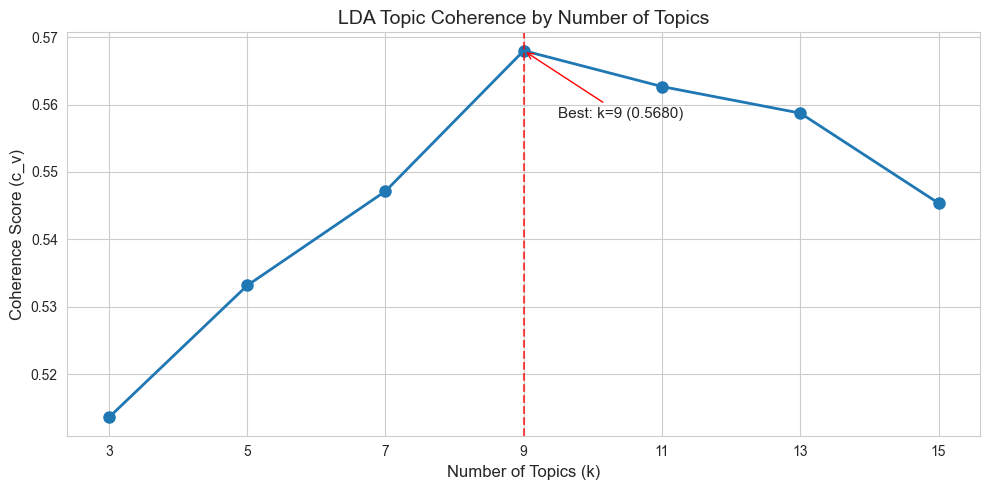


Optimal k = 9 (coherence = 0.5680)


In [9]:
# Plot coherence scores
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(coherence_df['k'], coherence_df['coherence'], 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Topics (k)', fontsize=12)
ax.set_ylabel('Coherence Score (c_v)', fontsize=12)
ax.set_title('LDA Topic Coherence by Number of Topics', fontsize=14)
ax.set_xticks(coherence_df['k'])

# Mark best k
best_k = coherence_df.loc[coherence_df['coherence'].idxmax(), 'k']
best_score = coherence_df['coherence'].max()
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7)
ax.annotate(f'Best: k={int(best_k)} ({best_score:.4f})',
            xy=(best_k, best_score), fontsize=11,
            xytext=(best_k + 0.5, best_score - 0.01),
            arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.savefig('../../Figures/Unsupervised_Outputs/lda_coherence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nOptimal k = {int(best_k)} (coherence = {best_score:.4f})")

## 5. Fit Final LDA Model

In [10]:
OPTIMAL_K = int(best_k)
print(f"Fitting final LDA model with k={OPTIMAL_K}...")

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=OPTIMAL_K,
    random_state=42,
    passes=20,
    alpha='auto',
    eta='auto',
    chunksize=2000
)

Fitting final LDA model with k=9...


In [11]:
# Print topics
print(f"\n{'='*70}")
print(f"LDA TOPICS (k={OPTIMAL_K})")
print(f"{'='*70}")

for idx, topic in lda_model.print_topics(num_words=10):
    print(f"\nTopic {idx}:")
    # Parse and display cleanly
    words = re.findall(r'"(\w+)"', topic)
    weights = re.findall(r'(0\.\d+)', topic)
    for w, wt in zip(words, weights):
        print(f"  {w:<20} {float(wt):.4f}")


LDA TOPICS (k=9)

Topic 0:
  arm                  0.0350
  sleeve               0.0300
  skirt                0.0270
  shoulder             0.0270
  lace                 0.0260
  bottom               0.0240
  issue                0.0220
  dinner               0.0210
  photo                0.0190
  see                  0.0170

Topic 1:
  first                0.0500
  zipper               0.0440
  another              0.0260
  tried                0.0240
  hard                 0.0220
  zip                  0.0210
  help                 0.0200
  experience           0.0200
  available            0.0200
  put                  0.0190

Topic 2:
  compliment           0.0480
  loved                0.0450
  length               0.0340
  color                0.0340
  night                0.0330
  heel                 0.0290
  wedding              0.0270
  received             0.0220
  many                 0.0210
  event                0.0190

Topic 3:
  gold                 0.0380
  black     

## 6. Topic Distribution Analysis

In [12]:
# Get topic distributions for each document
def get_topic_distribution(model, corpus, num_topics):
    """Extract topic probability vectors for all documents."""
    topic_dists = []
    for doc_bow in corpus:
        topic_probs = dict(model.get_document_topics(doc_bow, minimum_probability=0))
        row = [topic_probs.get(i, 0.0) for i in range(num_topics)]
        topic_dists.append(row)
    return np.array(topic_dists)


# Inference for EVERY review (train + test) with the train-fit model.
topic_matrix = get_topic_distribution(lda_model, corpus_all, OPTIMAL_K)
topic_cols = [f'topic_{i}' for i in range(OPTIMAL_K)]
topic_df = pd.DataFrame(topic_matrix, columns=topic_cols, index=rtw_reviews.index)

# Add dominant topic
topic_df['dominant_topic'] = topic_matrix.argmax(axis=1)
topic_df['dominant_topic_prob'] = topic_matrix.max(axis=1)

# Merge back
rtw_reviews = rtw_reviews.join(topic_df)

print(f"Topic distribution shape: {topic_matrix.shape}")
print(f"\nDominant topic distribution:")
print(rtw_reviews['dominant_topic'].value_counts().sort_index())

Topic distribution shape: (176562, 9)

Dominant topic distribution:
dominant_topic
0     1331
1      333
2    94816
3      125
4     6194
5    72806
6      318
7        7
8      632
Name: count, dtype: int64


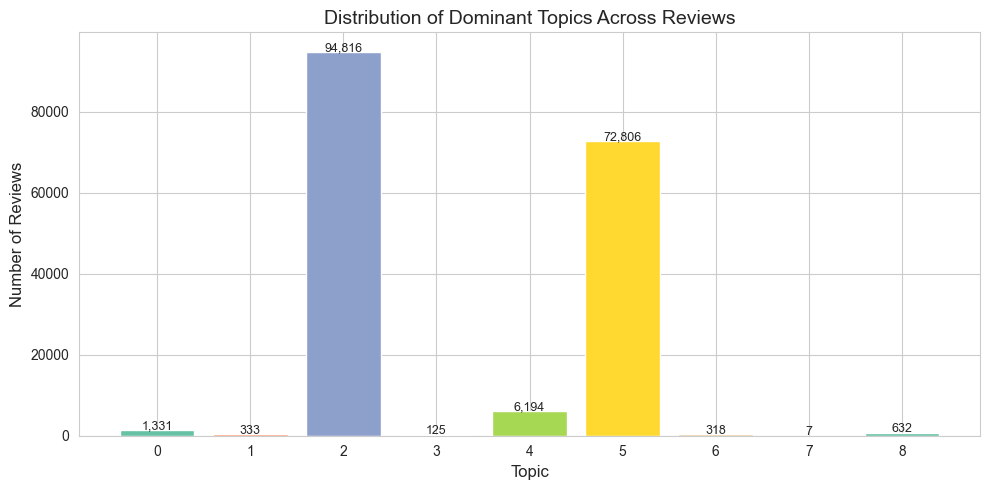

In [13]:
# Plot dominant topic distribution
fig, ax = plt.subplots(figsize=(10, 5))
topic_counts = rtw_reviews['dominant_topic'].value_counts().sort_index()
bars = ax.bar(topic_counts.index, topic_counts.values, color=sns.color_palette('Set2', OPTIMAL_K))
ax.set_xlabel('Topic', fontsize=12)
ax.set_ylabel('Number of Reviews', fontsize=12)
ax.set_title('Distribution of Dominant Topics Across Reviews', fontsize=14)
ax.set_xticks(range(OPTIMAL_K))

for bar, count in zip(bars, topic_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../../Figures/Unsupervised_Outputs/lda_topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Topics × Fit Outcome

Do different fit outcomes (small/fit/large) have distinct topic signatures?

In [14]:
# Average topic distribution by fit outcome
fit_topic_avg = rtw_reviews.groupby('fit')[topic_cols].mean()
fit_topic_avg = fit_topic_avg.reindex(['small', 'fit', 'large'])

print("Average Topic Proportions by Fit Outcome:\n")
print(fit_topic_avg.round(4).to_string())

Average Topic Proportions by Fit Outcome:

       topic_0  topic_1  topic_2  topic_3  topic_4  topic_5  topic_6  topic_7  topic_8
fit                                                                                   
small   0.1036   0.0593   0.2561   0.0358   0.1343   0.2792   0.0390   0.0285   0.0643
fit     0.1016   0.0549   0.2761   0.0401   0.1426   0.2451   0.0436   0.0272   0.0688
large   0.0994   0.0540   0.2534   0.0382   0.1311   0.2788   0.0458   0.0294   0.0698


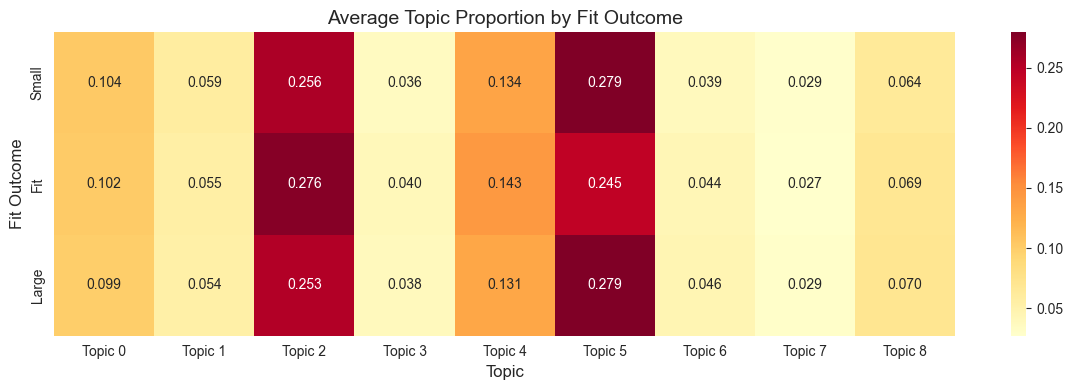

In [15]:
# Heatmap: fit outcome × topic
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    fit_topic_avg, annot=True, fmt='.3f', cmap='YlOrRd',
    xticklabels=[f'Topic {i}' for i in range(OPTIMAL_K)],
    yticklabels=['Small', 'Fit', 'Large'],
    ax=ax
)
ax.set_title('Average Topic Proportion by Fit Outcome', fontsize=14)
ax.set_xlabel('Topic', fontsize=12)
ax.set_ylabel('Fit Outcome', fontsize=12)
plt.tight_layout()
plt.savefig('../../Figures/Unsupervised_Outputs/lda_fit_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

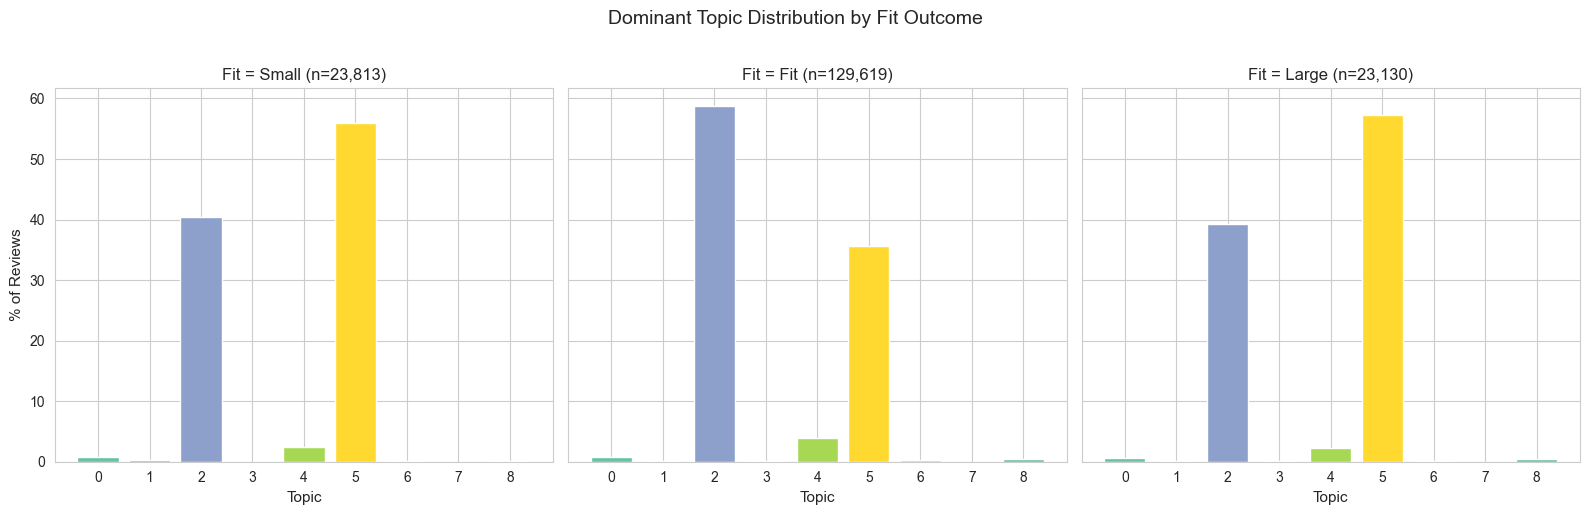

In [16]:
# Dominant topic distribution by fit outcome
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, fit_val in zip(axes, ['small', 'fit', 'large']):
    subset = rtw_reviews[rtw_reviews['fit'] == fit_val]
    counts = subset['dominant_topic'].value_counts().sort_index()
    pcts = counts / len(subset) * 100
    ax.bar(pcts.index, pcts.values, color=sns.color_palette('Set2', OPTIMAL_K))
    ax.set_title(f'Fit = {fit_val.capitalize()} (n={len(subset):,})', fontsize=12)
    ax.set_xlabel('Topic', fontsize=11)
    ax.set_xticks(range(OPTIMAL_K))
    if ax == axes[0]:
        ax.set_ylabel('% of Reviews', fontsize=11)

plt.suptitle('Dominant Topic Distribution by Fit Outcome', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../../Figures/Unsupervised_Outputs/lda_topic_by_fit.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Topic × Body Type Analysis

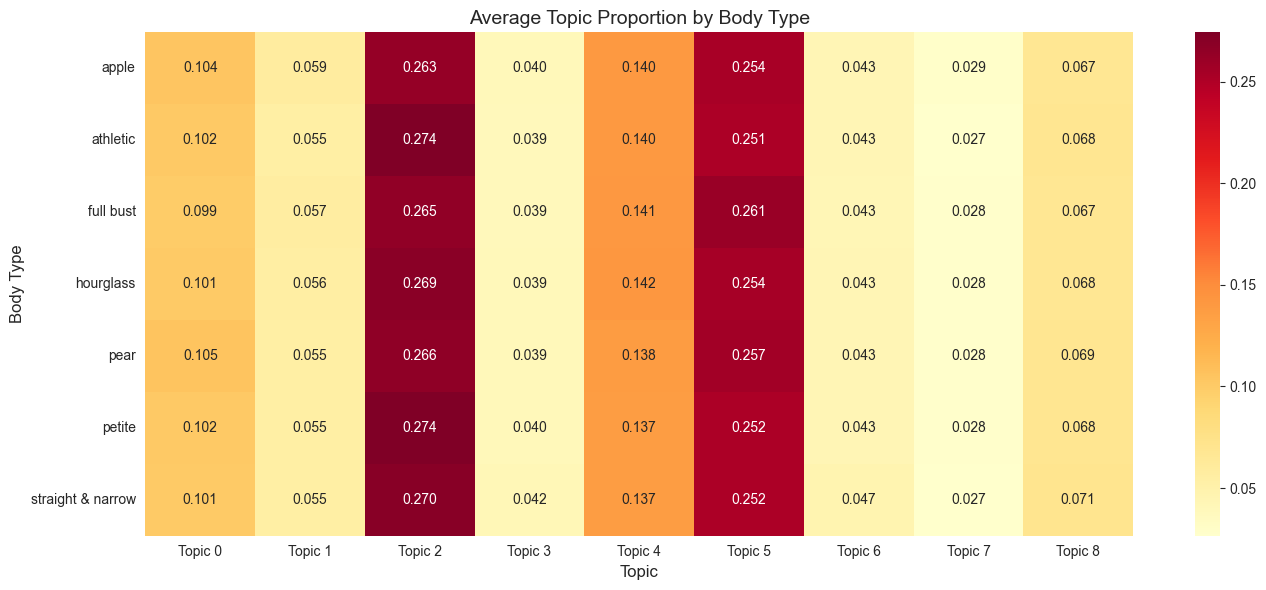

In [17]:
# Average topic distribution by body type
body_topic_avg = rtw_reviews.dropna(subset=['body_type']).groupby('body_type')[topic_cols].mean()

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    body_topic_avg, annot=True, fmt='.3f', cmap='YlOrRd',
    xticklabels=[f'Topic {i}' for i in range(OPTIMAL_K)],
    ax=ax
)
ax.set_title('Average Topic Proportion by Body Type', fontsize=14)
ax.set_xlabel('Topic', fontsize=12)
ax.set_ylabel('Body Type', fontsize=12)
plt.tight_layout()
plt.savefig('../../Figures/Unsupervised_Outputs/lda_topic_by_bodytype.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Topic × Category Analysis

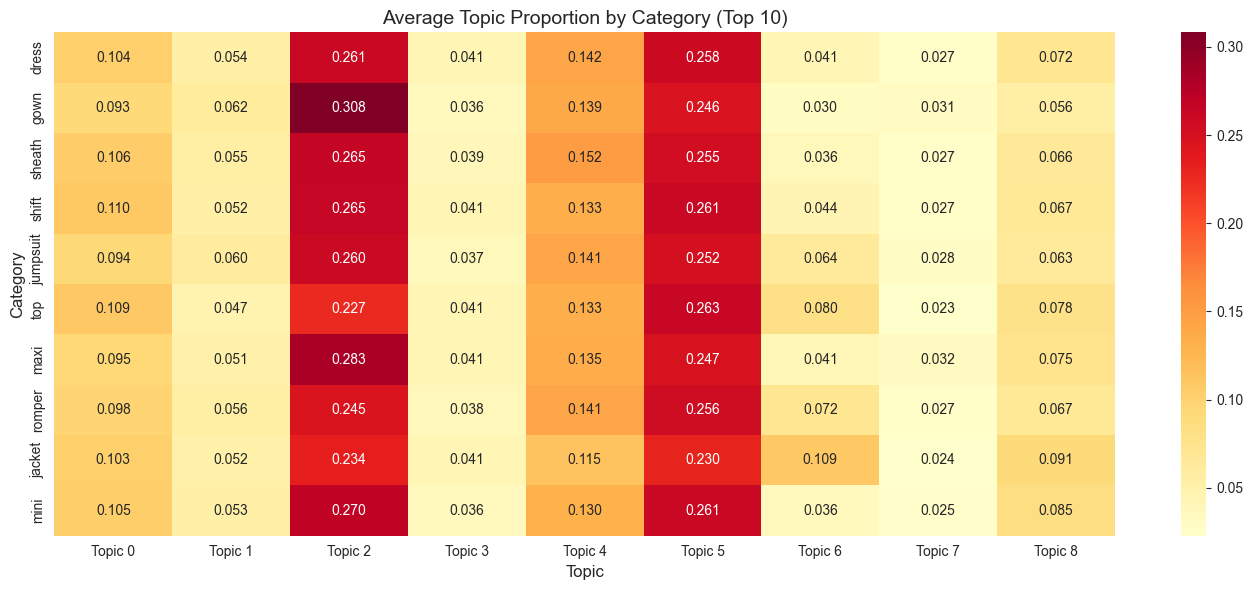

In [18]:
# Top 10 categories by volume
top_cats = rtw_reviews['category'].value_counts().head(10).index
cat_topic_avg = rtw_reviews[rtw_reviews['category'].isin(top_cats)].groupby('category')[topic_cols].mean()
cat_topic_avg = cat_topic_avg.loc[top_cats]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    cat_topic_avg, annot=True, fmt='.3f', cmap='YlOrRd',
    xticklabels=[f'Topic {i}' for i in range(OPTIMAL_K)],
    ax=ax
)
ax.set_title('Average Topic Proportion by Category (Top 10)', fontsize=14)
ax.set_xlabel('Topic', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
plt.tight_layout()
plt.savefig('../../Figures/Unsupervised_Outputs/lda_topic_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Interactive Visualization (pyLDAvis)

In [19]:
try:
    # Visualize the train-fit model over its train corpus.
    vis_data = pyLDAvis.gensim_models.prepare(lda_model, corpus, dictionary)
    pyLDAvis.save_html(vis_data, '../../Figures/Unsupervised_Outputs/lda_visualization.html')
    print("Saved interactive visualization: ../../Figures/Unsupervised_Outputs/lda_visualization.html")
    pyLDAvis.display(vis_data)
except Exception as e:
    print(f"pyLDAvis failed (install with: pip install pyLDAvis): {e}")

Saved interactive visualization: ../../Figures/Unsupervised_Outputs/lda_visualization.html


## 11. Representative Reviews per Topic

In [20]:
print(f"\n{'='*70}")
print("REPRESENTATIVE REVIEWS PER TOPIC")
print(f"{'='*70}")

for topic_id in range(OPTIMAL_K):
    # Get reviews where this topic is dominant with highest probability
    topic_reviews = rtw_reviews[rtw_reviews['dominant_topic'] == topic_id]
    top_reviews = topic_reviews.nlargest(3, 'dominant_topic_prob')

    print(f"\n--- Topic {topic_id} ({len(topic_reviews):,} reviews) ---")

    # Topic words
    words = [w for w, _ in lda_model.show_topic(topic_id, topn=8)]
    print(f"Keywords: {', '.join(words)}")

    for _, row in top_reviews.iterrows():
        text = str(row['review_text'])[:200]
        fit_val = row['fit']
        prob = row['dominant_topic_prob']
        print(f"\n  [{fit_val.upper()}] (prob={prob:.3f})")
        print(f"  {text}...")


REPRESENTATIVE REVIEWS PER TOPIC

--- Topic 0 (1,331 reviews) ---
Keywords: arm, sleeve, skirt, shoulder, lace, bottom, issue, dinner

  [FIT] (prob=0.374)
  Pretty lace but tank underneath was so see through!!! I would not expect such a nice quality item to have this issue! Wore my own tank underneath instead, but would have looked nicer with the tank it ...

  [SMALL] (prob=0.371)
  This is one of those dresses that looks really fantastic but is a little uncomfortable to wear. The lace sort of chaffed the inside of my elbows and I kept having to pull up the slip over my boobs. At...

  [FIT] (prob=0.371)
  I just wore this dress to take engagement photos, and it worked out perfectly. It was comfortable and fun. There is a bit of added poof in the skirt, which was sort of strange when sitting down. If si...

--- Topic 1 (333 reviews) ---
Keywords: first, zipper, another, tried, hard, zip, help, experience

  [FIT] (prob=0.396)
  This dress was not my original rental.  I rented two ot

## 12. Save Topic Features for Phase 2

In [21]:
output_cols = ['user_id', 'item_id', 'fit', 'fit_label'] + topic_cols + ['dominant_topic', 'dominant_topic_prob']
topic_output = (
    rtw_reviews[output_cols]
    .drop_duplicates(subset=['user_id', 'item_id', 'fit', 'fit_label'])
    .reset_index(drop=True)
)
assert not topic_output.duplicated(subset=['user_id', 'item_id', 'fit', 'fit_label']).any()
topic_output.to_csv('../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv', index=False)
print(f"Saved: ../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")
print(f"Shape: {topic_output.shape}")
print(f"\nThese topic distributions become features for Phase 2 classifiers.")

Saved: ../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv
Shape: (176329, 15)

These topic distributions become features for Phase 2 classifiers.


## 13. Summary

**Key findings:**
 - Optimal number of topics: k = {OPTIMAL_K}
 - Topic distributions vary by fit outcome → useful features for prediction
 - Topics capture distinct aspects of fit language (e.g., sizing complaints, fabric/comfort, occasion-appropriateness, body-shape fit)
 - Saved topic features to `Data/Processed/renttherunway_lda_topics.csv` for use in Phase 2 classifiers

In [22]:
print(f"\n{'='*70}")
print(f"LDA COMPLETE")
print(f"{'='*70}")
print(f"  Topics:        {OPTIMAL_K}")
print(f"  Best coherence: {best_score:.4f}")
print(f"  Reviews modeled: {len(rtw_reviews):,}")
print(f"  Output saved:  Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")


LDA COMPLETE
  Topics:        9
  Best coherence: 0.5680
  Reviews modeled: 176,562
  Output saved:  Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv


> **⚠️ This write-up predates the train/test-split refactor and needs a refresh.**
> It describes a **k = 11** model fit on all 176,562 reviews. After restricting
> the dictionary and model fitting to the **141,199 training reviews** (leakage
> fix), the coherence sweep now selects **k = 9** (coherence ≈ 0.568), so the
> topic table, labels, and per-fit proportions below are out of date. The
> methodology (preprocessing, `alpha='auto'`/`eta='auto'`, `no_below=15`,
> `no_above=0.3`, inference via `get_document_topics`) is unchanged. Re-run the
> notebook and rewrite the sections below against the new topics.

# LDA Topic Modeling Results: RentTheRunway Review Analysis

## Overview

Latent Dirichlet Allocation (LDA) was applied to the review text of the RentTheRunway dataset to extract latent semantic themes and enrich the feature space for fit prediction. After preprocessing, the corpus consisted of 176,562 reviews. Coherence scores (c_v) were computed across k = 3 to 15 topics, and k = 11 was selected as the optimal configuration, yielding the highest interpretability alongside competitive coherence. The final model was trained with `alpha='auto'` and `eta='auto'` to allow the model to learn asymmetric Dirichlet priors, with 20 passes over the corpus.

---

## Preprocessing

Review text was lowercased, stripped of punctuation and numeric characters, tokenized, and lemmatized using NLTK's WordNetLemmatizer. A combined stopword list was applied, merging NLTK's standard English stopwords with a custom set of domain-specific terms highly prevalent in clothing reviews (e.g., *wear*, *size*, *rental*, *order*, *item*). These terms were removed because their near-universal frequency across reviews would otherwise drive a degenerate catch-all topic. The Gensim dictionary was built from the resulting token lists and filtered using `no_below=15` and `no_above=0.3`, removing tokens appearing in fewer than 15 documents or more than 30% of the corpus.

---

## Feature Engineering

The topic probability scores for each review are appended to the dataset as features `topic_0 … topic_{k-1}`, along with `dominant_topic` and `dominant_topic_prob`. These features are incorporated into the supervised classification phase (Phase 2) alongside structured user and item features to predict fit outcome (Small / Fit / Large). Reviews are matched to transactions on `(user_id, item_id, fit, fit_label)`; the artifact is de-duplicated on that key.
